7.1

In [11]:
import numpy as np
from numpy import linalg as la

#determinant
A = np.array([1,2,3, 0,-4,1, 0,3,-1]).reshape(3,3)
det = la.det(A)
print('determinant A is: ', det)

#solution
b = np.array([2,2,-1])
X = la.solve(A, b) 
print(A, ".(x,y,z) =", X)

#orthogonal?
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")
print(f"\nInverse of A:\n{la.inv(A)}")
print(f"\nis equal to the transpose:\n{A.T}")
print(f"\nAlternative check with function array_equal(): {np.array_equal(A.T, la.inv(A))}")
print(f"\nAlternative check with function allclose(): {np.allclose(A.T, la.inv(A))}")
print(f"A is not orthogonal")
#eigenvalues
Lambda, v = la.eig(A)
print("Lambda = ", Lambda)



determinant A is:  1.0
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]] .(x,y,z) = [10. -1. -2.]

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]

Inverse of A:
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]

is equal to the transpose:
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

Alternative check with function array_equal(): False

Alternative check with function allclose(): False
A is not orthogonal
Lambda =  [ 1.         -4.79128785 -0.20871215]


7.3

In [49]:
import numpy as np
from numpy import linalg as la

# Define rotation matrices
def Ez(gamma_deg):
    gamma = np.deg2rad(gamma_deg)
    return np.array([np.cos(gamma),np.sin(gamma),0, -np.sin(gamma),np.cos(gamma),0, 0,0,1]).reshape(3,3)


def Ey(beta_deg):
    beta = np.deg2rad(beta_deg)
    return np.array([np.cos(beta),0,-np.sin(beta), 0,1,0, np.sin(beta),0,np.cos(beta)]).reshape(3,3)


# Angles from equation (7.15)
alpha = 180 - 123       
beta  = 90 - 27.4       
gamma = 192.25          

#use eq 7.15
E = Ez(alpha) @ Ey(beta) @ Ez(gamma)
print(E)

#prove it is rotation matrix by showing orthogonal and computing determinant
det = la.det(E)
print('det must be non zero, det is:',det)
print(f"\nE.ET should be the identity matrix:\n{E@E.T}")
print(f"\nInverse of E:\n{la.inv(E)}")
print(f"\nis equal to the transpose:\n{E.T}")
print(f"A is orthogonal, cause inverse equals transpose")
print(f"E is orthogonal and det is nonzero, so it is a rotation matrix")

#eigenvalue
Lambda, v = la.eig(E)
print("Lambda = ", Lambda)
print("one real value found")

#prove that v follows from equation (7.16) and that the norm of v is 1.0.
alpha2_deg = 192.25
delta_deg = 27.4
alpha2 = np.deg2rad(alpha2_deg)
delta = np.deg2rad(delta_deg)

x = np.cos(delta)*np.cos(alpha2)
y = np.cos(delta)*np.sin(alpha2)
z = np.sin(delta)
v = np.array([x, y, z])
print(f"v = [{x}, {y}, {z}]")
norm = la.norm(v)
print(f"norm of v is: {norm}")

#prove that when you rotate vector v with rotation matrix E, the result is a vector v2 with only z-component
V = v/norm #normalize
v2 = E @ V #rotate
print(f"v2 is: {v2}")

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]
det must be non zero, det is: 0.9999999999999999

E.ET should be the identity matrix:
[[ 1.00000000e+00 -5.93384238e-17 -2.27866584e-18]
 [-5.93384238e-17  1.00000000e+00  1.26395432e-16]
 [-2.27866584e-18  1.26395432e-16  1.00000000e+00]]

Inverse of E:
[[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]

is equal to the transpose:
[[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]
A is orthogonal, cause inverse equals transpose
E is orthogonal and det is nonzero, so it is a rotation matrix
Lambda =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
one real value found
v = [-0.8676008111514348, -0.18837460172292037, 0.46019978478385165]
norm of v is: 1.0
v2 is: [2.45631360e-17 2.95515309e-17 1.00000000e+00]


7.5

[ 2.18582332e+02 -5.51003145e+02  5.65812236e+02 -3.13633555e+02
  1.04544074e+02 -2.19331359e+01  2.91867714e+00 -2.39059755e-01
  1.09925609e-02 -2.17117476e-04]


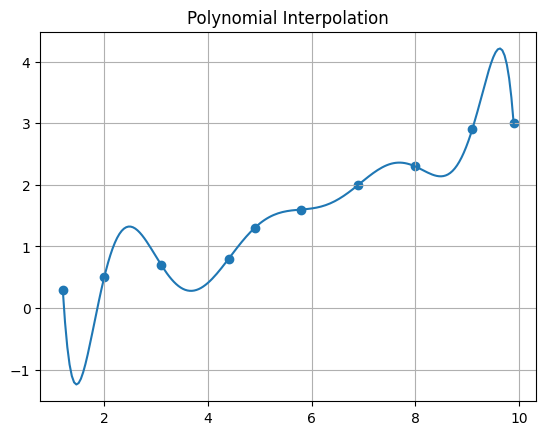

In [3]:
import numpy as np
from numpy import linalg as la
import matplotlib.pyplot as plt

#data
x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

#build matrix using loop
A = np.zeros((len(x), len(x)))
for i in range(len(x)):
    for j in range(len(x)):
        A[i, j] = x[i]**j  
        
#coefficients
coeff = la.solve(A, y)
print(coeff)

# Evaluate polynomial (using loops)
x_plot = np.linspace(min(x), max(x), 200)
y_plot = np.zeros_like(x_plot)

for i in range(len(x_plot)):
    for j in range(len(x)):
        y_plot[i] += coeff[j] * (x_plot[i]**j)

# Plot
plt.figure()
plt.scatter(x, y)
plt.plot(x_plot, y_plot)
plt.title("Polynomial Interpolation")
plt.grid()
plt.show()



7.6

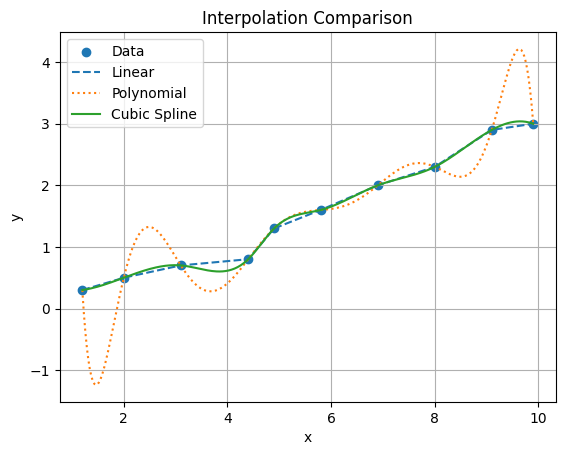

Any x-value:4
Linear: 0.7692307692307692
Polynomial: 0.4087454060880873
Spline: 0.6136397161926068


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import interpolate as ip
import numpy.linalg as la

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


class Interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
       
        # Linear interpolation
        self.linear_func = ip.interp1d(x, y, kind='linear')
       
        # Cubic spline interpolation
        self.spline_func = ip.interp1d(x, y, kind='cubic')
       
        # Polynomial interpolation 
        n = len(x)
        A = np.zeros((n, n))
        for i in range(n):
            for j in range(n):
                A[i, j] = x[i] ** j
       
        self.coeffs = la.solve(A, y)
   
    def polynomial(self, x_val):
        result = 0
        for j in range(len(self.coeffs)):
            result += self.coeffs[j] * (x_val ** j)
        return result
   
    def interpolate(self, x_val, method="spline"):
        if method == "linear":
            return self.linear_func(x_val)
        elif method == "polynomial":
            return self.polynomial(x_val)
        elif method == "spline":
            return self.spline_func(x_val)
        else:
            raise ValueError("Choose: 'linear', 'polynomial', or 'spline'")


interp = Interpolation(x, y)


x_plot = np.linspace(min(x), max(x), 300)

y_linear = interp.interpolate(x_plot, "linear")
y_spline = interp.interpolate(x_plot, "spline")

# Polynomial evaluated with loops
y_poly = np.zeros_like(x_plot)
for i in range(len(x_plot)):
    for j in range(len(interp.coeffs)):
        y_poly[i] += interp.coeffs[j] * (x_plot[i] ** j)

# Plotting
plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(x_plot, y_linear, linestyle='--', label="Linear")
plt.plot(x_plot, y_poly, linestyle=':', label="Polynomial")
plt.plot(x_plot, y_spline, label="Cubic Spline")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Interpolation Comparison")
plt.legend()
plt.grid()
plt.show()

# Test
x = float(input("Any x-value:"))
print("Linear:", interp.interpolate(x, "linear"))
print("Polynomial:", interp.interpolate(x, "polynomial"))
print("Spline:", interp.interpolate(x, "spline"))



7.7

In [10]:
import numpy as np

# 2x2 pixel values
I = np.array([[2.0, 4.1],
              [2.5, 3.8]])

def bilinearIP(I, col, row):
    rowlen, collen = I.shape
    i = int(row)
    j = int(col)
   
    mu = row - i
    Lambda = col - j
   
    I0 = I[i, j]
    I1 = I[i,j+1]
    I2 = I[i+1, j]
    I3 = I[i+1,j+1]
   
    Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return Iintp

# Fractional coordinates
x = 0.2  
y = 0.7  

# Compute interpolated intensity
I_ip = bilinearIP(I, x, y)
print(f"Interpolated intensity at x={x}, y={y} is {I_ip}")


Interpolated intensity at x=0.2, y=0.7 is 2.658


7.10

Hubble constant from leastsq:    H0 = 66.03 km/s/Mpc
Hubble constant from curve_fit: H0 = 66.03 ± 0.83 km/s/Mpc


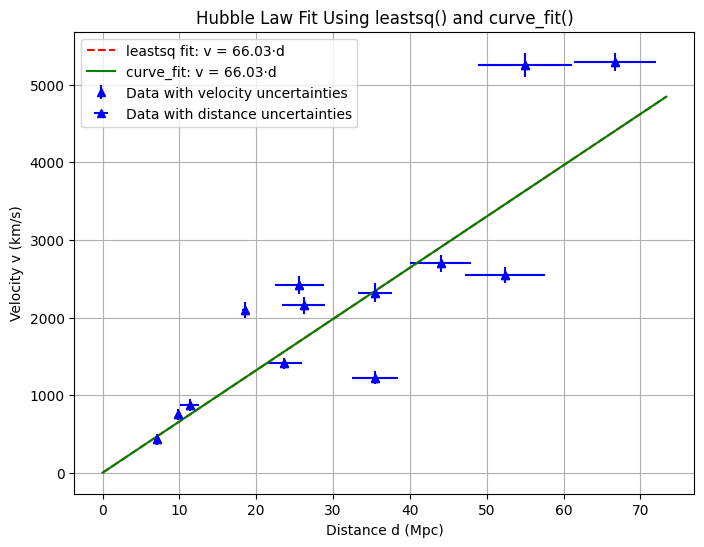

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

#Data
raw = [
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]

data = np.array(raw).reshape(-1,4)
d     = data[:,0]   
v     = data[:,1]   
err_d = data[:,2]
err_v = data[:,3]   

#leastsq() fit with velocity uncertainties 

def residuals(H, d, v, err_v):
    return (v - H*d)/err_v

H0_guess = 70   # initial guess for Hubble constant
H_leastsq, *_ = leastsq(residuals, H0_guess, args=(d, v, err_v))

#curve_fit() fit with weights 

def hubble_model(d, H):
    return H * d

popt, pcov = curve_fit(hubble_model, d, v, sigma=err_v, absolute_sigma=True, p0=[70])
H_curvefit     = popt[0]
H_curvefit_err = np.sqrt(np.diag(pcov))[0]

#Print
print(f"Hubble constant from leastsq:    H0 = {H_leastsq[0]:.2f} km/s/Mpc")
print(f"Hubble constant from curve_fit: H0 = {H_curvefit:.2f} ± {H_curvefit_err:.2f} km/s/Mpc")

#Plot the data and both fits 

plt.figure(figsize=(8,6))

plt.errorbar(d, v, yerr=err_v, fmt='^', color='blue', label='Data with velocity uncertainties')
plt.errorbar(d, v, xerr=err_d, fmt='^', color='blue', label='Data with distance uncertainties')


d_fit = np.linspace(0, d.max()*1.1, 200)
plt.plot(d_fit, H_leastsq[0]*d_fit, '--', color='red',
         label=f'leastsq fit: v = {H_leastsq[0]:.2f}·d')
plt.plot(d_fit, H_curvefit*d_fit,  '-', color='green',
         label=f'curve_fit: v = {H_curvefit:.2f}·d')

plt.xlabel('Distance d (Mpc)')
plt.ylabel('Velocity v (km/s)')
plt.title('Hubble Law Fit Using leastsq() and curve_fit()')
plt.legend()
plt.grid()
plt.show()

7.14